<a href="https://colab.research.google.com/github/helgadenes/Computational_Physics_USFQ/blob/main/Unit_3/3_9_integrals_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrals (data)


## Example:

Recall the example of evolving mixed fractions of pigments in a wind-cloud simulation.


We have three mixing fractions (one for each pigment) versus time, and we want to calculate:

1) the rate at which the pigments mix, and

2) the total amount of mixed mass of each pigment evaluated from such rate.

3) compare that to the actual amount of mixed mass at the final time.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
dir = "drive/MyDrive/Colab Notebooks/CP_1/Unit_3/"

Mounted at /content/drive


In [7]:
df = pd.read_csv(dir+"data_wind_cloud_mix.dat", sep = "\s+")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4785941.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(dir+"data_wind_cloud_mix.dat", sep = "\s+")


In [8]:
print(df)

        Time  MixedMass1  MixedMass2  MixedMass3
0   0.000000    0.000000    0.000000    0.000000
1   0.099800    0.024878    0.000000    0.024878
2   0.199956    0.030227    0.039161    0.050699
3   0.299681    0.039424    0.831349    0.693602
4   0.399916    0.056870    1.259453    1.030902
..       ...         ...         ...         ...
81  8.099956    4.622937   20.646380    8.763763
82  8.199907    5.035324   21.111130    8.756436
83  8.299865    5.456865   21.501670    8.721914
84  8.399680    5.874080   21.845740    8.669781
85  8.499951    6.259131   22.012070    8.606597

[86 rows x 4 columns]


In [9]:
time = np.array(df["Time"])

pigment1 = np.array(df["MixedMass1"])
pigment2 = np.array(df["MixedMass2"])
pigment3 = np.array(df["MixedMass3"])

In [10]:
#print(time.shape, pigment1.shape)

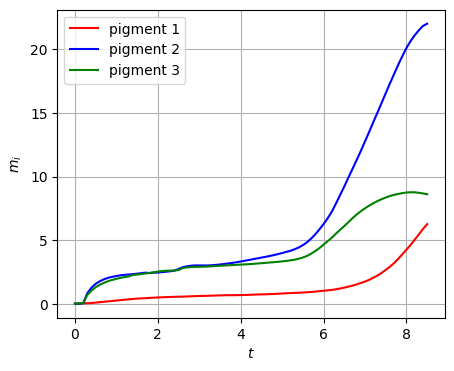

In [11]:
# Fig enviroment

fig, ax = plt.subplots(figsize=(5,4))

ax.plot(time, pigment1, c='red', label = "pigment 1")
ax.plot(time, pigment2, c='blue', label = "pigment 2")
ax.plot(time, pigment3, c='green', label = "pigment 3")

plt.grid()

plt.legend()

plt.xlabel(r"$t$")
plt.ylabel(r"$m_i$")

plt.show()

## Get mixing rate:

In [14]:
# 2nd order derivatives
dpigment1 = np.gradient(pigment1, time[1]-time[0], axis = 0)
dpigment2 = np.gradient(pigment2, time[1]-time[0], axis = 0)
dpigment3 = np.gradient(pigment3, time[1]-time[0], axis = 0)

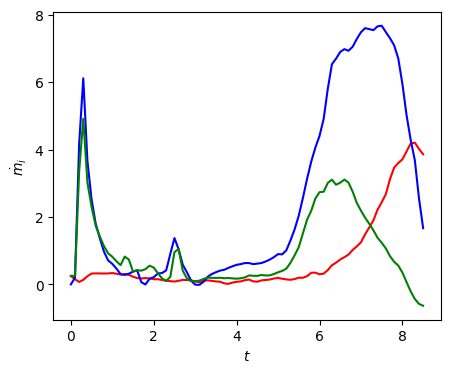

In [15]:
# Fig enviroment

fig, ax = plt.subplots(figsize=(5,4))

ax.plot(time, dpigment1, c='red', label = "pigment 1")
ax.plot(time, dpigment2, c='blue', label = "pigment 2")
ax.plot(time, dpigment3, c='green', label = "pigment 3")
plt.xlabel(r"$t$")
plt.ylabel(r"$\dot{m}_i$")

plt.show()

## Total mixed mass

The total mixed mass of each pigment corresponds to the last value of each array of the original data:


In [16]:
print(pigment1[-1])
print(pigment2[-1])
print(pigment3[-1])

6.259131
22.01207
8.606597


## Get integral under curves:

Another way is to integrate the curves of the change in mass, the values should be close to the ones above:

In [20]:
import scipy as sc

from scipy import integrate

### Trapezoid method:

In [23]:
# Let's integrate the derivative function

sc_trapezoid1 = sc.integrate.trapezoid(dpigment1,time)
sc_trapezoid2 = sc.integrate.trapezoid(dpigment2,time)
sc_trapezoid3 = sc.integrate.trapezoid(dpigment3,time)

In [24]:
print(sc_trapezoid1)
print(sc_trapezoid2)
print(sc_trapezoid3)

6.272066740479672
22.05621029467118
8.623665485850836


### Simpson method:

In [25]:
sc_simpson1 = sc.integrate.simpson(dpigment1,time)
sc_simpson2 = sc.integrate.simpson(dpigment2,time)
sc_simpson3 = sc.integrate.simpson(dpigment3,time)

In [26]:
print(sc_simpson1)
print(sc_simpson2)
print(sc_simpson3)

6.274500613353028
22.069158587089888
8.623957111417068
